In [1]:
import os
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d as spline

import TwoPUtils as tpu
import STX3KO_analyses as stx

rng = np.random.default_rng()

%matplotlib inline


%load_ext autoreload
%autoreload 2 

In [2]:
nl_kwta = stx.wta.KWTA(eta=0, tau=0, w_norm_decay = 0, ca1_noise= .5, w_sigma_mag = 1E-3, w_max=10, ca3_sigma_mag=.05, n_winners=50 )
nl_ca1 = nl_kwta.run_trials()

In [147]:
l_kwta = stx.wta.KWTA(eta=1E-4, tau=0, w_norm_decay = 9E-4,ca1_noise= 1., w_sigma_mag = 1E-3, w_max=10, ca3_sigma_mag = .05, n_winners=50)
l_ca1 = l_kwta.run_trials()

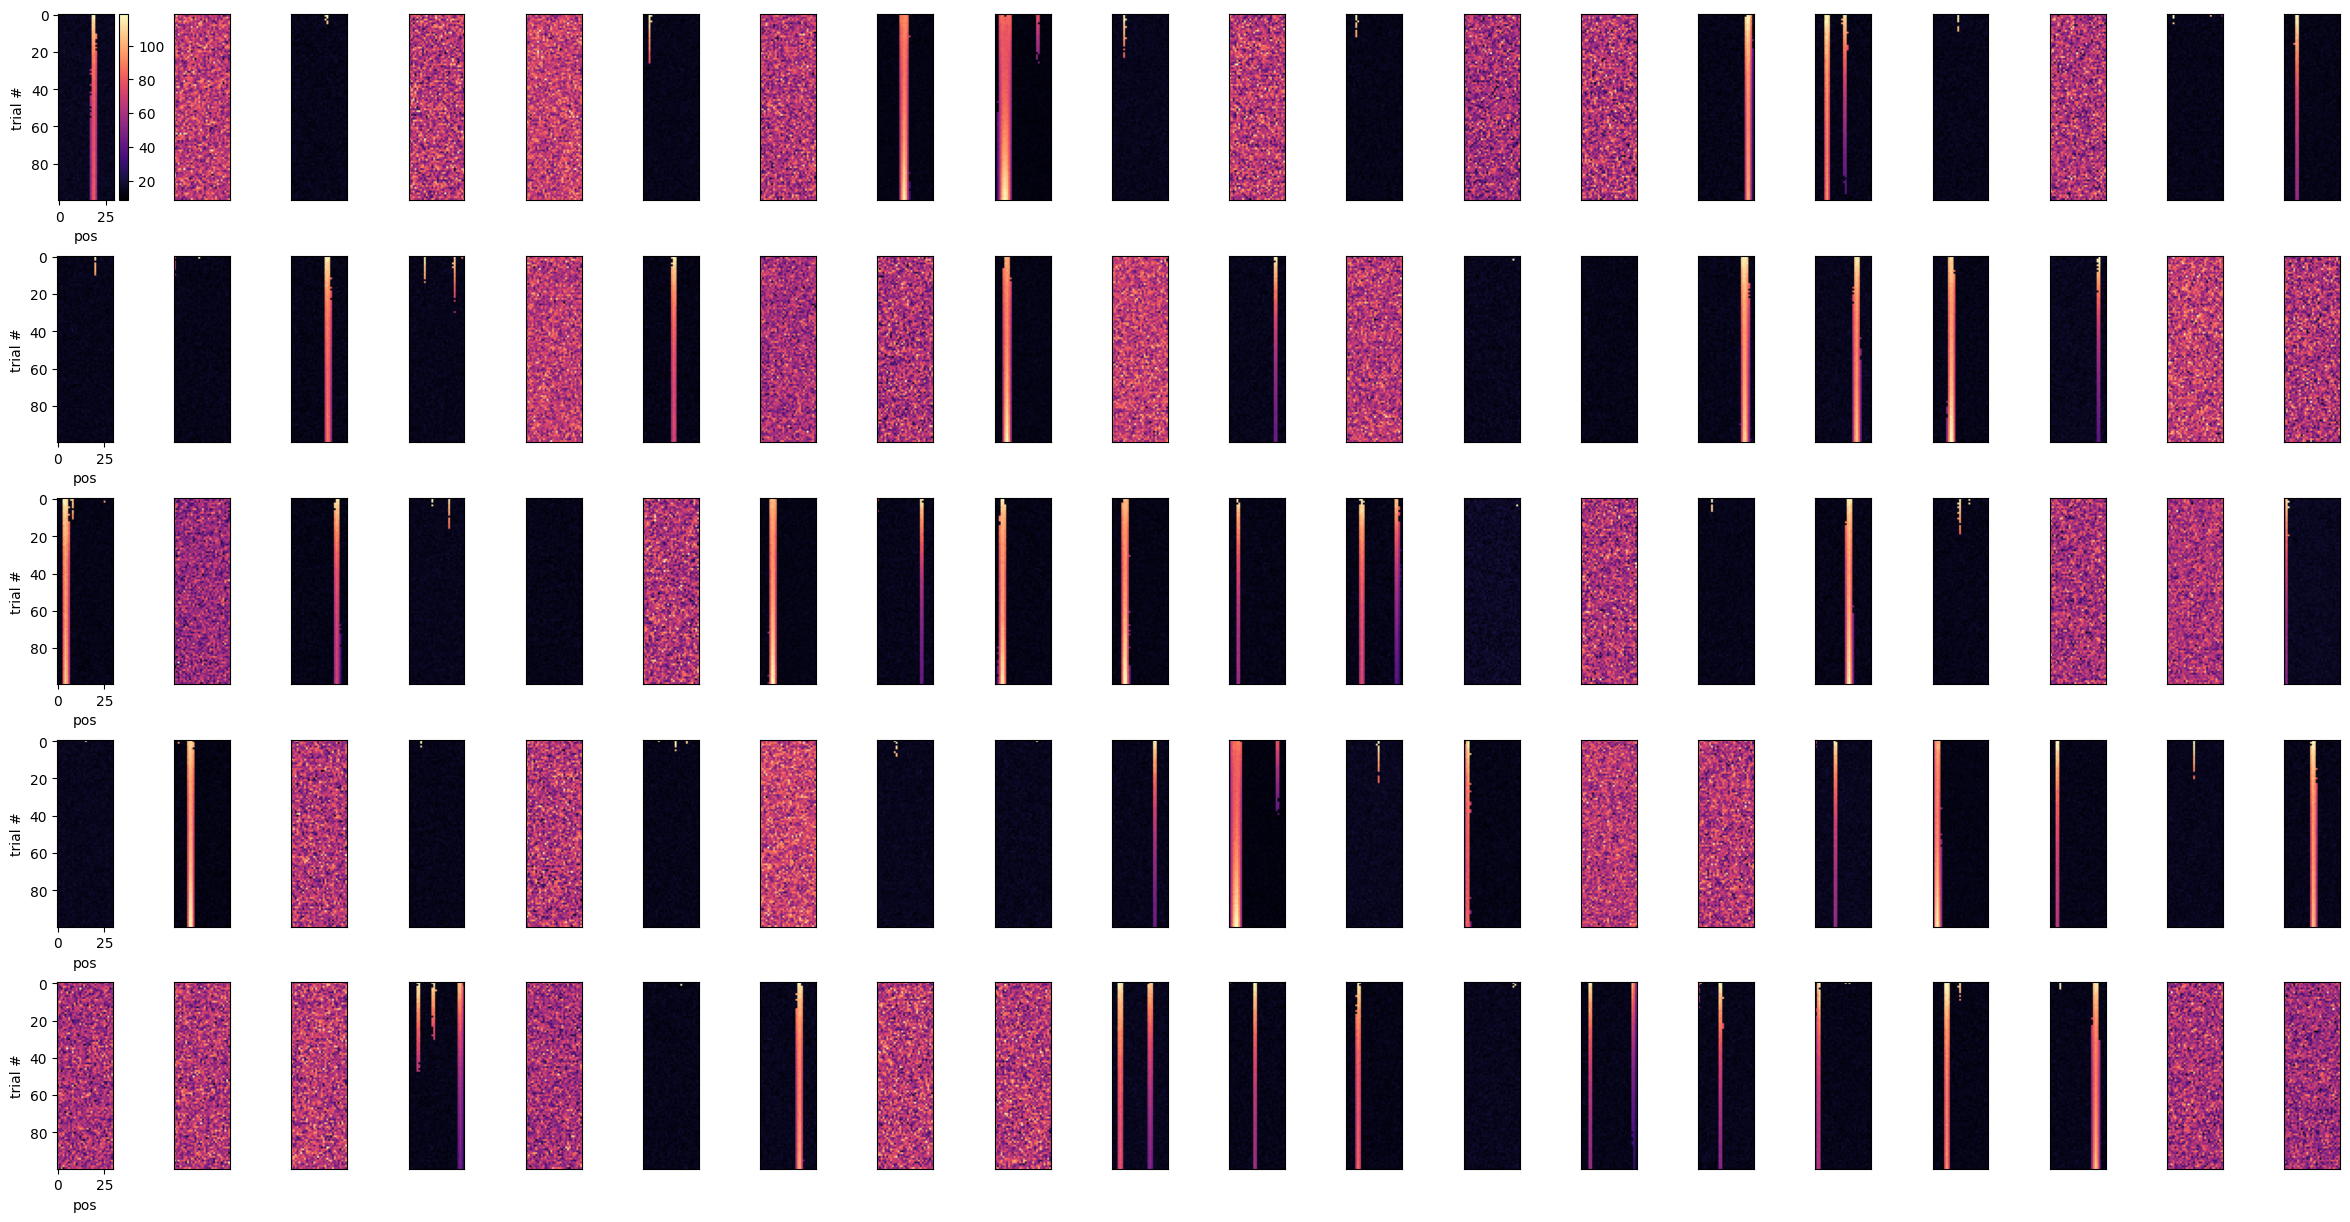

In [148]:
lpop_fig = stx.wta.plot_cells(l_ca1, cell_inds = np.arange(0,100))

In [ ]:
# def __init__(self, n_pos=30, w_max=100, n_ca3=1000, n_ca1=1000, n_winners=100,
#                  eta=1E-4, tau=1E-5, eta_ctrl=None, max_pos=10, ca3_sigma_mag=.08,
#                  weight_dist='lognormal', w_sigma_mag=1E-3, w_norm_decay=1E-3, ca1_noise=1, ca3_width = .5):

In [149]:
rng = np.random.default_rng()

n_ca1 = 1000
pcnt_infected = .5
eta = rng.random(size=[n_ca1,1])
infected_mask = eta<=pcnt_infected
eta = 1E-5*infected_mask
sparse_kwta = stx.wta.KWTA(eta=eta, tau=0, w_norm_decay = 0,ca1_noise= 1., w_sigma_mag = 1E-3, w_max=10, ca3_sigma_mag = .05, n_winners=50)
sparse_ca1 = sparse_kwta.run_trials()


In [150]:
sparse_ca1.shape

(100, 30, 1000)

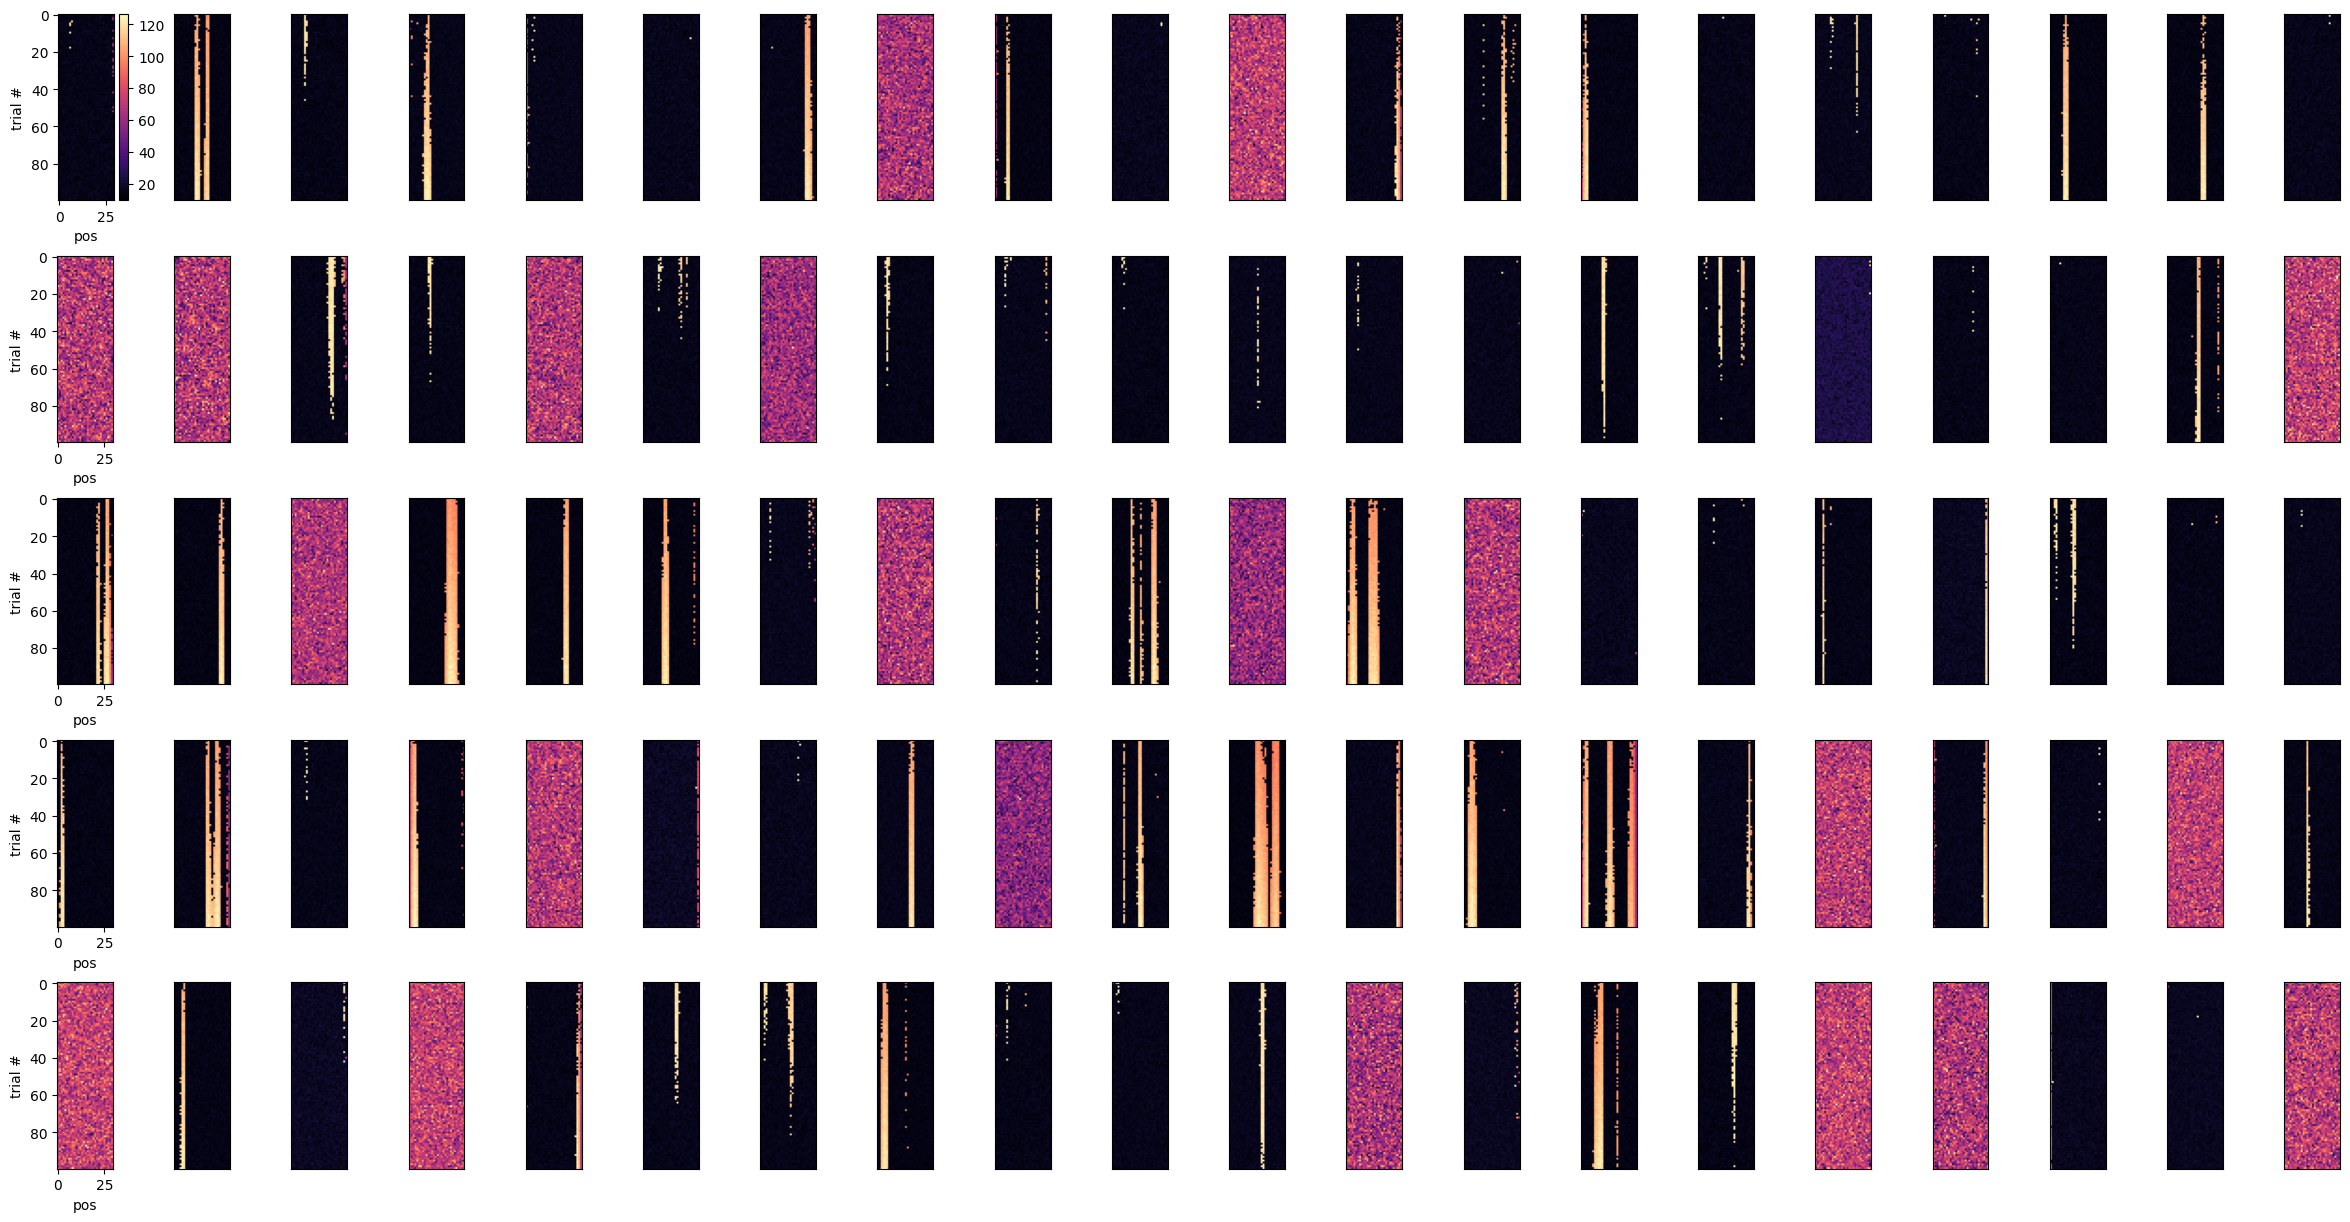

In [151]:
sparse_pop_fig = stx.wta.plot_cells(sparse_ca1[:,:,:], cell_inds = np.arange(0,100))

In [152]:
occ = np.ones([30,])/30

ko_trial_mat = sparse_ca1[:,:,~infected_mask.ravel()]
ctrl_trial_mat = sparse_ca1[:,:,infected_mask.ravel()]

ko_si = tpu.spatial_analyses.spatial_info(ko_trial_mat[50:,:,:].mean(axis=0),occ)
ctrl_si = tpu.spatial_analyses.spatial_info(ctrl_trial_mat[50:,:,:].mean(axis=0),occ)



(array([190.,   5.,   5.,  12.,  30.,  58.,  52.,  89.,  59.,  16.]),
 array([0.02063294, 0.35627214, 0.69191135, 1.02755055, 1.36318976,
        1.69882897, 2.03446817, 2.37010738, 2.70574658, 3.04138579,
        3.37702499]),
 <BarContainer object of 10 artists>)

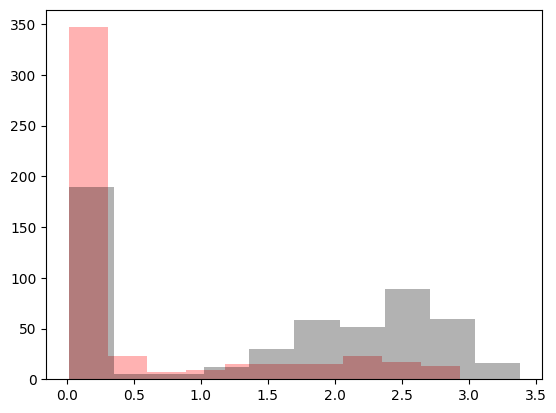

In [153]:
fig,ax = plt.subplots()
ax.hist(ko_si, color='red', alpha=.3)
ax.hist(ctrl_si, color='black', alpha=.3)

In [154]:
ko_mask = ko_si>1
ctrl_mask = ctrl_si>1


ctrl_fw = stx.spatial_analyses.field_width(ctrl_trial_mat[:,:,ctrl_mask].mean(axis=0))
ko_fw = stx.spatial_analyses.field_width(ko_trial_mat[:,:,ko_mask].mean(axis=0))

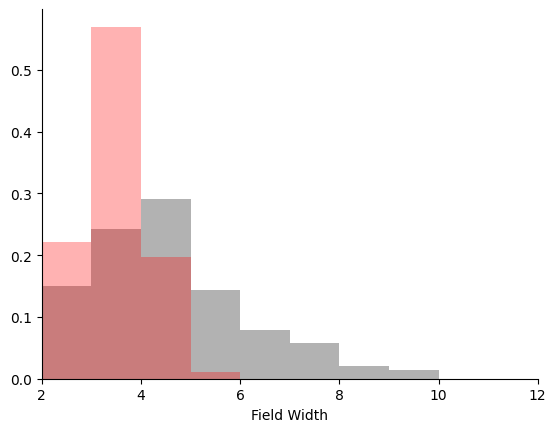

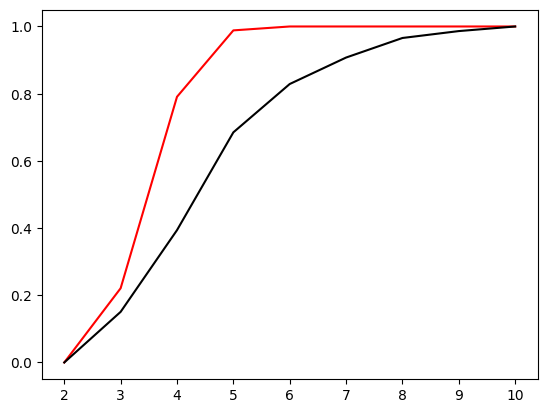

In [155]:
bins = np.arange(1,11)
fig,ax = plt.subplots()
ko_hist, bins, _ = ax.hist(ko_fw, bins = bins, color='red', alpha=.3,density=True)
ctrl_hist, bins, _ = ax.hist(ctrl_fw,bins=bins, color='black', alpha=.3, zorder=-1,density=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Field Width')
ax.set_xlim([2, 12])

fig, ax = plt.subplots()
ax.plot(bins[1:], np.cumsum(ko_hist), color='red')
ax.plot(bins[1:], np.cumsum(ctrl_hist), color='black')


In [156]:
ctrl_peaks = stx.spatial_analyses.max_counts(ctrl_trial_mat[:,:,ctrl_mask].mean(axis=0))
ko_peaks = stx.spatial_analyses.max_counts(ko_trial_mat[:,:,ko_mask].mean(axis=0))

(1.0, 5.0)

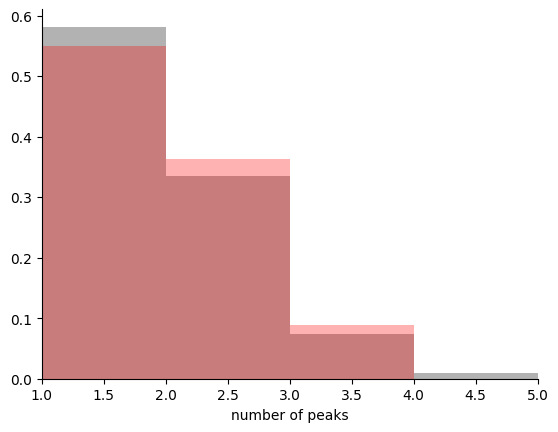

In [157]:
bins = np.arange(1,6)
fig,ax = plt.subplots()
ko_hist, bins, _ = ax.hist(ko_peaks[ko_peaks>0], bins = bins, color='red', alpha=.3,density=True)
ctrl_hist, bins, _ = ax.hist(ctrl_peaks[ctrl_peaks>0],bins=bins, color='black', alpha=.3, zorder=-1,density=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('number of peaks')
ax.set_xlim([1,5])
